Simulation of light and eutrophication
Author: Marc López  
Course: Computational Marine Ecological Modelling  
Date: 2026

# 1. Introduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
#Same Grid Ex2
depth = 100
Nz = 50

z = np.linspace(0, depth, Nz)
dz = z[1] - z[0]

In [3]:
g_p_max = 1.0
k_L = 20
k_N = 0.3

g_z_max = 1.0
k_P = 1.0

eps = 0.3
eps_f = 0.3

m_p = 0.07
m_z = 0.2

r = 0.1

N_deep = 10
kappa = 0.3
L0 = 1400


k_O = 5
y_P = 9
O_surface = 260

# mixing scenario switch
high_mixing = False

In [4]:
def mixing_depth(t, z_mix_min=10, z_mix_max=60):

    z_mix = 0.5 * (1 - np.sin(2*np.pi*t/365)) * (z_mix_max - z_mix_min) + z_mix_min

    return z_mix

In [5]:
def diffusivity(z, t, k_surface=50, k_bottom=0.1, zeta=5):
    z_mix = mixing_depth(t)
    
    # 1. Valores corregidos. 2. Eliminamos el "5*"
    kappa = 0.5 * (1 - np.tanh((z - z_mix)/zeta)) * (k_surface - k_bottom) + k_bottom
    
    return kappa

In [6]:
def light_profile(P, z, L0, kw=0.04, kp=0.03):

    cumulative_P = np.cumsum(P) * dz
    
    light = L0 * np.exp(-(kw*z + kp*cumulative_P))
    
    return light

In [7]:
def light_profile_water_only(z, L0, kw=0.04):

    light = L0 * np.exp(-kw * z)

    return light

In [8]:
def surface_light(t, Lmax=1400):

    L = Lmax * (0.5 + 0.5*np.sin(2*np.pi*(t-80)/365))

    return L

In [9]:
# Variables with vertical dimension
N = np.linspace(10,1,Nz)
P = np.ones(Nz)*0.05
Z = np.ones(Nz)*0.02
D = np.ones(Nz)*0.02
O = np.zeros(Nz)
y0 = np.concatenate([N, P, Z, D, O])

In [10]:
def npzd_water_column(t, y):

    N = y[0:Nz]
    P = y[Nz:2*Nz]
    Z = y[2*Nz:3*Nz]
    D = y[3*Nz:4*Nz]
    O = y[4*Nz:5*Nz]

    L_surface = surface_light(t)

    if use_phyto_shading:
        light = light_profile(P, z, L_surface)
    else:
        light = light_profile_water_only(z, L_surface)

    global high_mixing
    
    kappa_z = diffusivity(z, t)

    if high_mixing:
        kappa_z = np.ones(Nz) * 50

    dN = np.zeros(Nz)
    dP = np.zeros(Nz)
    dZ = np.zeros(Nz)
    dD = np.zeros(Nz)
    dO = np.zeros(Nz)


    for i in range(Nz):
        # growth rates
        g_p = g_p_max * min(light[i]/(light[i]+k_L), N[i]/(N[i]+k_N))
        grazing = g_z_max * Z[i] * P[i] / (P[i] + k_P)

        # oxygen limitation
        O_switch = O[i] / (O[i] + k_O)

        dN[i] = - g_p*P[i] + eps*grazing + r*D[i]*O_switch
        dP[i] = g_p*P[i] - grazing - m_p*P[i]
        dZ[i] = (1-eps-eps_f)*grazing - m_z*Z[i]
        dD[i] = m_p*P[i] + m_z*Z[i] + eps_f*grazing - r*D[i]*O_switch

        # oxygen dynamics
        production = y_P * g_p * P[i]
        consumption = y_P * r * D[i] * O_switch
        dO[i] = production - consumption

    # 2. Difusión vertical (solo capas internas)
    for i in range(1, Nz-1):
        dN[i] += kappa_z[i] * (N[i+1] - 2*N[i] + N[i-1]) / dz**2
        dP[i] += kappa_z[i] * (P[i+1] - 2*P[i] + P[i-1]) / dz**2
        dZ[i] += kappa_z[i] * (Z[i+1] - 2*Z[i] + Z[i-1]) / dz**2
        dD[i] += kappa_z[i] * (D[i+1] - 2*D[i] + D[i-1]) / dz**2
        dO[i] += kappa_z[i] * (O[i+1] - 2*O[i] + O[i-1]) / dz**2

    # 3. Condiciones de contorno (Fondo: z = Nz-1)
    dN[-1] += kappa_z[-1] * (N_deep - N[-1]) / dz**2 + kappa_z[-1] * (N[-2] - N[-1]) / dz**2
    dP[-1] += kappa_z[-1] * (P[-2] - P[-1]) / dz**2
    dZ[-1] += kappa_z[-1] * (Z[-2] - Z[-1]) / dz**2
    dD[-1] += kappa_z[-1] * (D[-2] - D[-1]) / dz**2
    dO[-1] += kappa_z[-1] * (O[-2] - O[-1]) / dz**2

    # 4. Condiciones de contorno (Superficie: z = 0)
    v_gas = 20 # Velocidad de intercambio gaseoso (puedes ajustar si se provee un valor en clase)
    
    # Intercambio gaseoso del oxígeno + difusión con la capa de abajo
    dO[0] += v_gas * (O_surface - O[0]) / dz + kappa_z[0] * (O[1] - O[0]) / dz**2
    dN[0] += kappa_z[0] * (N[1] - N[0]) / dz**2
    dP[0] += kappa_z[0] * (P[1] - P[0]) / dz**2
    dZ[0] += kappa_z[0] * (Z[1] - Z[0]) / dz**2
    dD[0] += kappa_z[0] * (D[1] - D[0]) / dz**2

 
    return np.concatenate((dN, dP, dZ, dD, dO))

In [11]:
t_span = (0,365)
t_eval = np.linspace(0,365,365)

# Summer simulation sin phytoplankton shading

In [12]:
use_phyto_shading = False

sol_no_shading = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

# Summer simulation con phytoplankton shading

In [13]:
use_phyto_shading = True

sol_shading = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

# Results

In [14]:
N_no = sol_no_shading.y[0:Nz,-1]
P_no = sol_no_shading.y[Nz:2*Nz,-1]
Z_no = sol_no_shading.y[2*Nz:3*Nz,-1]
D_no = sol_no_shading.y[3*Nz:4*Nz,-1]
O_no = sol_no_shading.y[4*Nz:5*Nz,-1]

N_sh = sol_shading.y[0:Nz,-1]
P_sh = sol_shading.y[Nz:2*Nz,-1]
Z_sh = sol_shading.y[2*Nz:3*Nz,-1]
D_sh = sol_shading.y[3*Nz:4*Nz,-1]
O_sh = sol_shading.y[4*Nz:5*Nz,-1]

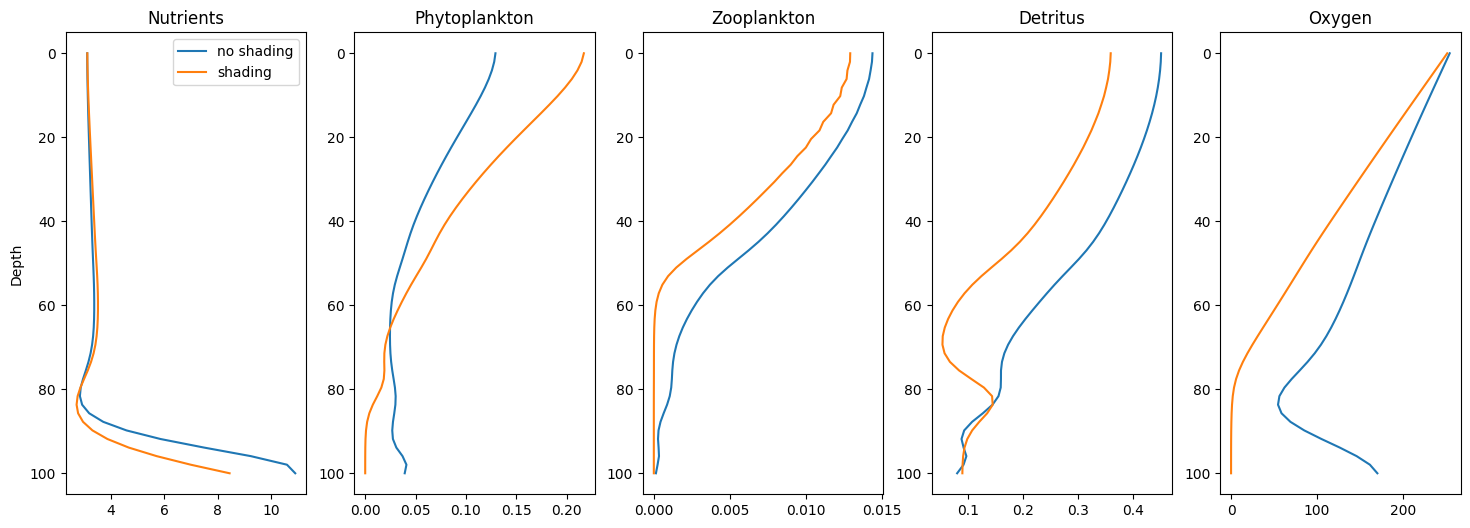

In [15]:
# comparar resultados
fig, ax = plt.subplots(1,5, figsize=(18,6))

ax[0].plot(N_no,z,label="no shading")
ax[0].plot(N_sh,z,label="shading")

ax[1].plot(P_no,z)
ax[1].plot(P_sh,z)

ax[2].plot(Z_no,z)
ax[2].plot(Z_sh,z)

ax[3].plot(D_no,z)
ax[3].plot(D_sh,z)

ax[4].plot(O_no,z)
ax[4].plot(O_sh,z)


ax[0].set_title("Nutrients")
ax[1].set_title("Phytoplankton")
ax[2].set_title("Zooplankton")
ax[3].set_title("Detritus")
ax[4].set_title("Oxygen")

ax[0].set_ylabel("Depth")

ax[0].legend()

for a in ax:
    a.invert_yaxis()

plt.show()

# Scenario: High nutrient input

In [16]:
N_deep = 100

use_phyto_shading = True

sol_eutrophic = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

In [17]:
P_eut = sol_eutrophic.y[Nz:2*Nz, -1]

In [18]:
Chl = P_eut / 8

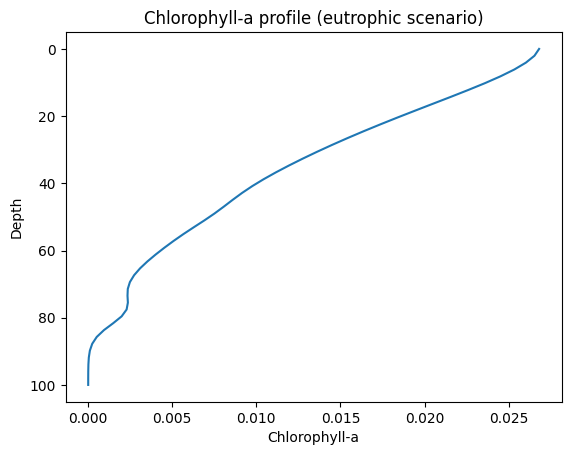

In [19]:
plt.plot(Chl, z)

plt.gca().invert_yaxis()

plt.xlabel("Chlorophyll-a")
plt.ylabel("Depth")

plt.title("Chlorophyll-a profile (eutrophic scenario)")

plt.show()

The chlorophyll-a concentration shows a maximum at intermediate depths (~10–20 m), where both light availability and nutrient concentration are sufficient for phytoplankton growth. This is a typical feature known as the deep chlorophyll maximum.

In [20]:
P_normal = sol_shading.y[Nz:2*Nz, -1]
Chl_normal = P_normal / 8

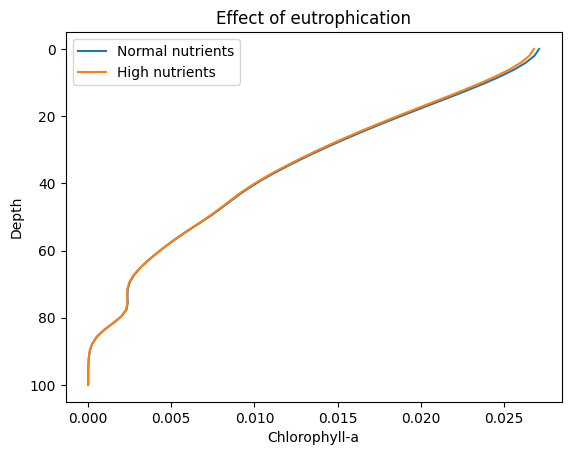

In [21]:
plt.plot(Chl_normal, z, label="Normal nutrients")
plt.plot(Chl, z, label="High nutrients")

plt.gca().invert_yaxis()

plt.xlabel("Chlorophyll-a")
plt.ylabel("Depth")

plt.title("Effect of eutrophication")

plt.legend()

plt.show()

Increasing the bottom nutrient concentration from 10 to 100 mmol N m⁻³ leads to a significant increase in phytoplankton biomass and chlorophyll-a concentrations throughout the water column. The eutrophic scenario shows a stronger chlorophyll maximum compared to the normal nutrient case, indicating enhanced phytoplankton growth due to higher nutrient availability. This behaviour is consistent with eutrophication processes where nutrient enrichment stimulates primary production.

In [22]:
print(z)

[  0.           2.04081633   4.08163265   6.12244898   8.16326531
  10.20408163  12.24489796  14.28571429  16.32653061  18.36734694
  20.40816327  22.44897959  24.48979592  26.53061224  28.57142857
  30.6122449   32.65306122  34.69387755  36.73469388  38.7755102
  40.81632653  42.85714286  44.89795918  46.93877551  48.97959184
  51.02040816  53.06122449  55.10204082  57.14285714  59.18367347
  61.2244898   63.26530612  65.30612245  67.34693878  69.3877551
  71.42857143  73.46938776  75.51020408  77.55102041  79.59183673
  81.63265306  83.67346939  85.71428571  87.75510204  89.79591837
  91.83673469  93.87755102  95.91836735  97.95918367 100.        ]


In [23]:
# Initial conditions NORMAL nutrients
N0_normal = np.ones(Nz) * 2
P0 = np.ones(Nz) * 0.1
Z0 = np.ones(Nz) * 0.1
D0 = np.ones(Nz) * 0.1
O0 = np.ones(Nz) * O_surface

y0_normal = np.concatenate([N0_normal, P0, Z0, D0, O0])


# Initial conditions HIGH nutrients
N0_eut = np.ones(Nz) * 10

y0_eut = np.concatenate([N0_eut, P0, Z0, D0, O0])

In [24]:
# Run simulation with normal nutrients
sol_normal = solve_ivp(npzd_water_column, [0, 365], y0_normal, method="RK45")
N_normal = sol_normal.y[0:Nz, -1]


# Run simulation with high nutrients
sol_eut = solve_ivp(npzd_water_column, [0, 365], y0_eut, method="RK45")
N_eut = sol_eut.y[0:Nz, -1]

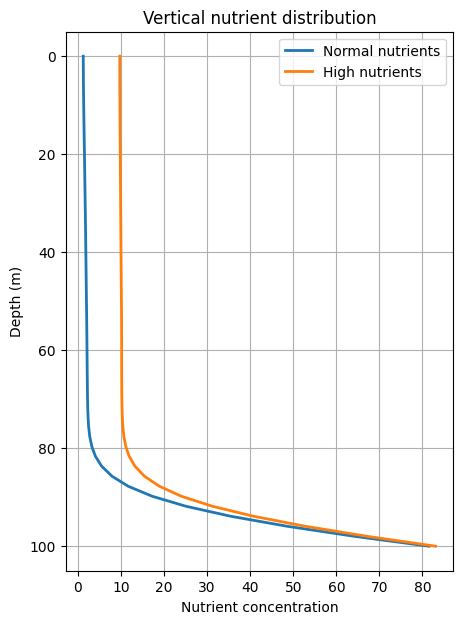

In [25]:
plt.figure(figsize=(5,7))

plt.plot(N_normal, z, linewidth=2, label="Normal nutrients")
plt.plot(N_eut, z, linewidth=2, label="High nutrients")

plt.gca().invert_yaxis()

plt.xlabel("Nutrient concentration")
plt.ylabel("Depth (m)")
plt.title("Vertical nutrient distribution")
plt.legend()
plt.grid()

plt.show()

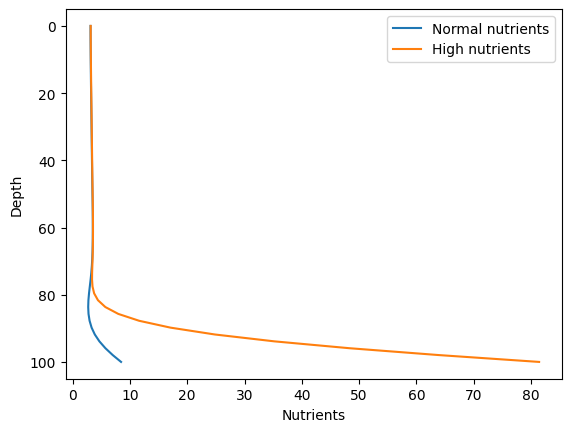

In [26]:
N_normal = sol_shading.y[0:Nz, -1]
N_eut = sol_eutrophic.y[0:Nz, -1]

plt.plot(N_normal, z, label="Normal nutrients")
plt.plot(N_eut, z, label="High nutrients")

plt.gca().invert_yaxis()
plt.xlabel("Nutrients")
plt.ylabel("Depth")
plt.legend()

# Seasonal simulation

In [27]:
# Seasonal simulation

t_span = (0,365 * 5)
t_eval = np.linspace(0,365,365)

use_phyto_shading = True

sol_seasonal = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

In [28]:
N_surface = sol_seasonal.y[0, :]
P_surface = sol_seasonal.y[Nz, :]
Z_surface = sol_seasonal.y[2*Nz, :]
D_surface = sol_seasonal.y[3*Nz, :]

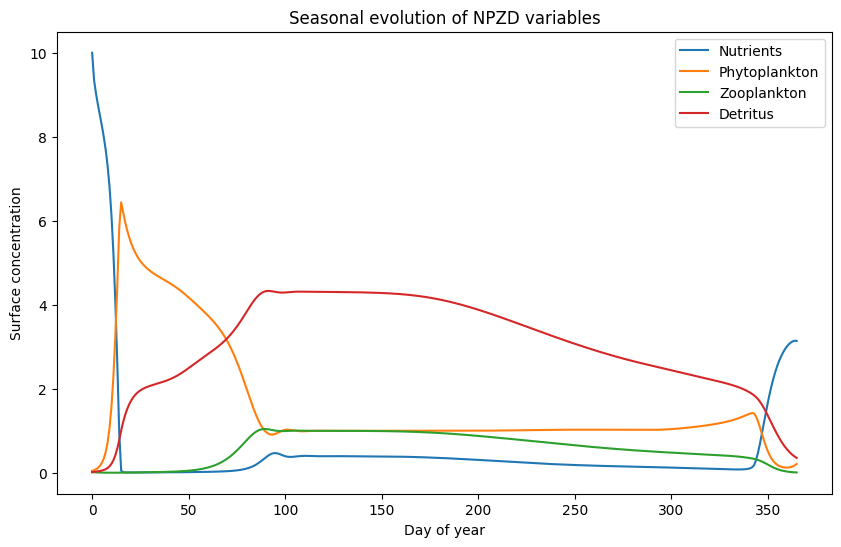

In [29]:
plt.figure(figsize=(10,6))

plt.plot(sol_seasonal.t, N_surface, label="Nutrients")
plt.plot(sol_seasonal.t, P_surface, label="Phytoplankton")
plt.plot(sol_seasonal.t, Z_surface, label="Zooplankton")
plt.plot(sol_seasonal.t, D_surface, label="Detritus")

plt.xlabel("Day of year")
plt.ylabel("Surface concentration")
plt.title("Seasonal evolution of NPZD variables")

plt.legend()
plt.show()

In [30]:
N_time = np.mean(sol_seasonal.y[0:Nz,:], axis=0)
P_time = np.mean(sol_seasonal.y[Nz:2*Nz,:], axis=0)
Z_time = np.mean(sol_seasonal.y[2*Nz:3*Nz,:], axis=0)
D_time = np.mean(sol_seasonal.y[3*Nz:4*Nz,:], axis=0)

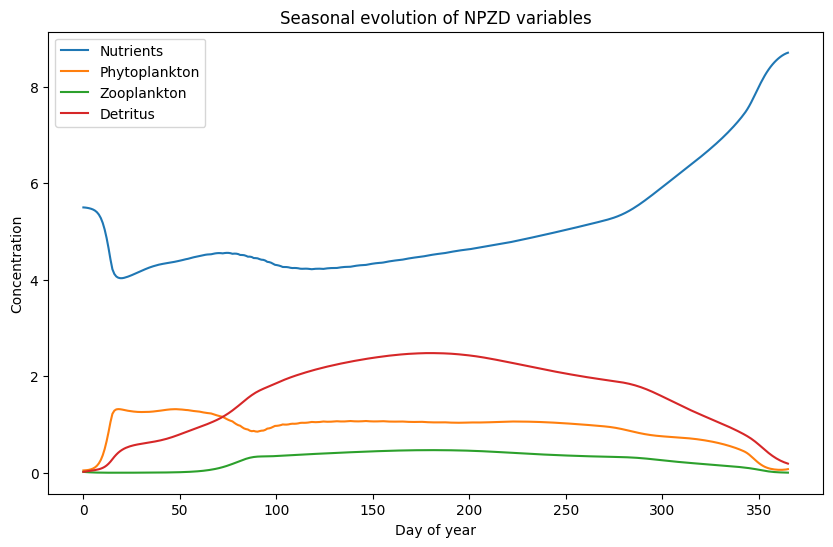

In [31]:
plt.figure(figsize=(10,6))

plt.plot(sol_seasonal.t, N_time, label="Nutrients")
plt.plot(sol_seasonal.t, P_time, label="Phytoplankton")
plt.plot(sol_seasonal.t, Z_time, label="Zooplankton")
plt.plot(sol_seasonal.t, D_time, label="Detritus")

plt.xlabel("Day of year")
plt.ylabel("Concentration")
plt.title("Seasonal evolution of NPZD variables")

plt.legend()
plt.show()

In [32]:
# perfil de luz
I0 = 200          # luz en superficie (ejemplo)
k_L = 0.04        # coeficiente de atenuación

I = I0 * np.exp(-k_L * z)

In [33]:
K_I = 20     # half-saturation constant for light
K_N = 0.5    # half-saturation constant for nutrients

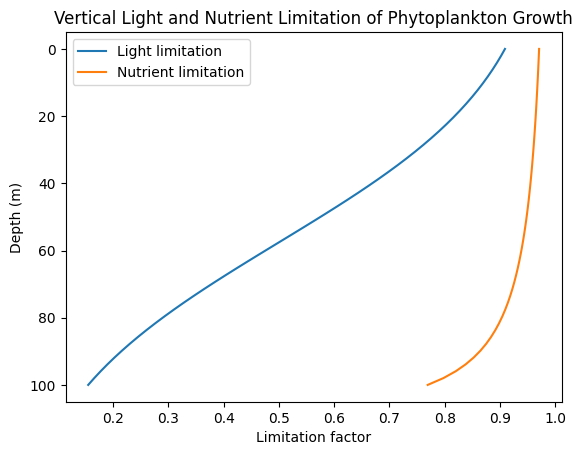

In [34]:
light_lim = I/(I+K_I)
nutrient_lim = N/(N+k_N)

plt.plot(light_lim, z, label="Light limitation")
plt.plot(nutrient_lim, z, label="Nutrient limitation")

plt.gca().invert_yaxis()
plt.xlabel("Limitation factor")
plt.ylabel("Depth (m)")
plt.title("Vertical Light and Nutrient Limitation of Phytoplankton Growth")
plt.legend()
plt.show()

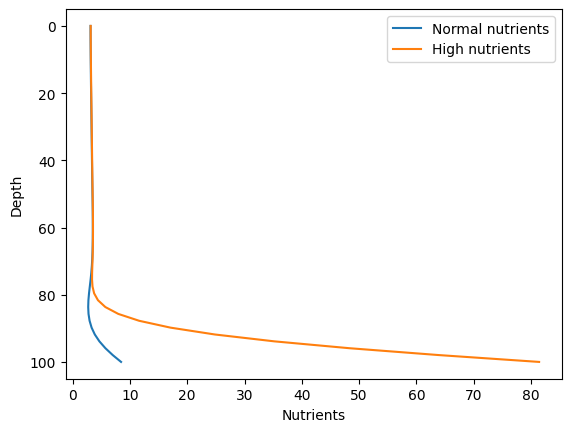

In [35]:
N_normal = sol_shading.y[0:Nz, -1]
N_eut = sol_eutrophic.y[0:Nz, -1]

plt.plot(N_normal, z, label="Normal nutrients")
plt.plot(N_eut, z, label="High nutrients")

plt.gca().invert_yaxis()
plt.xlabel("Nutrients")
plt.ylabel("Depth")
plt.legend()

# Oxygen scenario: stratified vs mixed water column

# Stratified Column

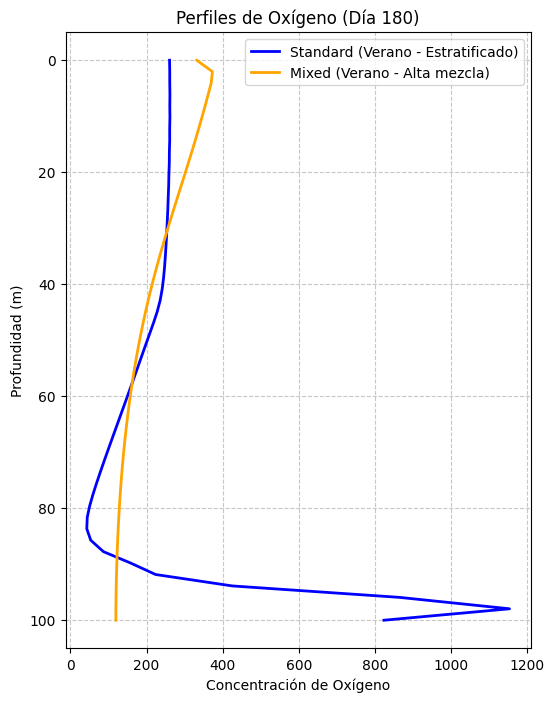

In [36]:
# =========================================================
# 1. FUNCIONES "ENVOLTORIO" (Forzan la variable global)
# =========================================================
def modelo_standard(t, y):
    global high_mixing
    high_mixing = False # Obligamos a que sea False en cada milisegundo de esta simulación
    return npzd_water_column(t, y)

def modelo_mixed(t, y):
    global high_mixing
    high_mixing = True  # Obligamos a que sea True en cada milisegundo de esta simulación
    return npzd_water_column(t, y)

# =========================================================
# 2. SIMULAR AMBOS ESCENARIOS (¡Sin Radau!)
# =========================================================
# Dejamos que Python use su método por defecto (RK45) que no hace suposiciones negativas
sol_standard = solve_ivp(modelo_standard, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_mixed = solve_ivp(modelo_mixed, [0, 365], y0, t_eval=np.linspace(0, 365, 365))

# =========================================================
# 3. EXTRAER Y GRAFICAR (Día 180 - Verano)
# =========================================================
dia_verano = 180

O_standard_summer = sol_standard.y[4*Nz:5*Nz, dia_verano]
O_mixed_summer = sol_mixed.y[4*Nz:5*Nz, dia_verano]

plt.figure(figsize=(6, 8))

plt.plot(O_standard_summer, z, label="Standard (Verano - Estratificado)", color='blue', linewidth=2)
plt.plot(O_mixed_summer, z, label="Mixed (Verano - Alta mezcla)", color='orange', linewidth=2)

plt.gca().invert_yaxis() 

plt.title(f"Perfiles de Oxígeno (Día {dia_verano})")
plt.xlabel("Concentración de Oxígeno")
plt.ylabel("Profundidad (m)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

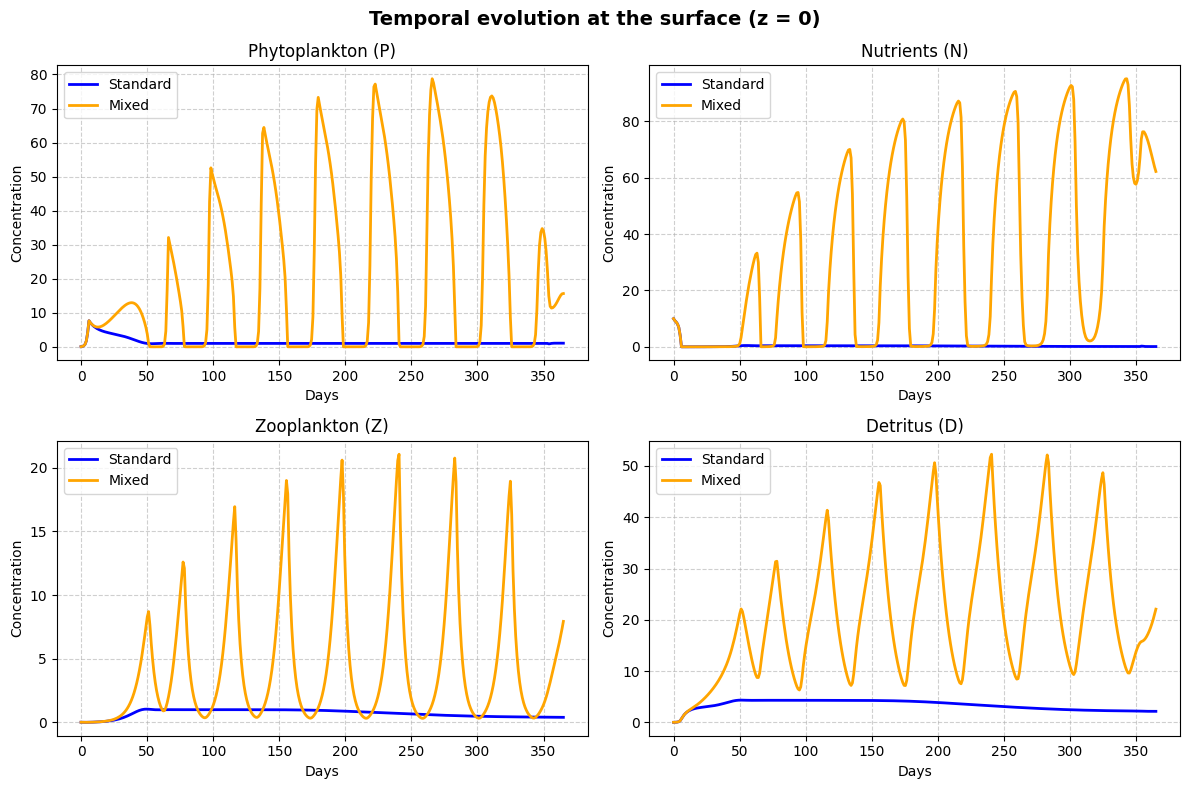

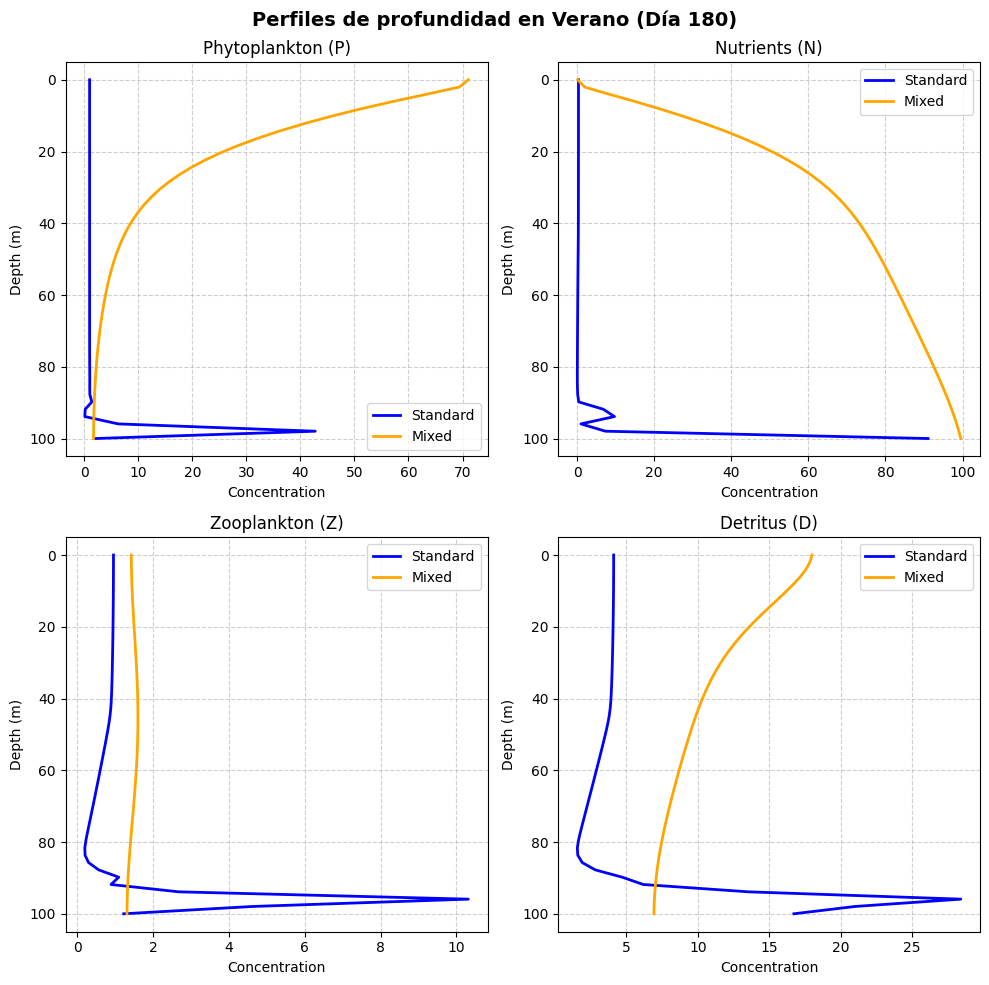

In [37]:
# =========================================================
# 1. EXTRAER TODAS LAS VARIABLES (Para ambos escenarios)
# =========================================================
# Escenario Standard
N_std = sol_standard.y[0:Nz, :]
P_std = sol_standard.y[Nz:2*Nz, :]
Z_std = sol_standard.y[2*Nz:3*Nz, :]
D_std = sol_standard.y[3*Nz:4*Nz, :]

# Escenario Mixed
N_mix = sol_mixed.y[0:Nz, :]
P_mix = sol_mixed.y[Nz:2*Nz, :]
Z_mix = sol_mixed.y[2*Nz:3*Nz, :]
D_mix = sol_mixed.y[3*Nz:4*Nz, :]

dias = sol_standard.t # El eje X para el tiempo

# =========================================================
# GRÁFICA 1: Evolución temporal en la SUPERFICIE (Capa 0)
# Corresponde a tu primera foto
# =========================================================
fig1, axs1 = plt.subplots(2, 2, figsize=(12, 8))
fig1.suptitle('Temporal evolution at the surface (z = 0)', fontsize=14, fontweight='bold')

# Fitoplancton
axs1[0, 0].plot(dias, P_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[0, 0].plot(dias, P_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[0, 0].set_title('Phytoplankton (P)')

# Nutrientes
axs1[0, 1].plot(dias, N_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[0, 1].plot(dias, N_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[0, 1].set_title('Nutrients (N)')

# Zooplancton
axs1[1, 0].plot(dias, Z_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[1, 0].plot(dias, Z_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[1, 0].set_title('Zooplankton (Z)')

# Detrito
axs1[1, 1].plot(dias, D_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[1, 1].plot(dias, D_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[1, 1].set_title('Detritus (D)')

for ax in axs1.flat:
    ax.set_xlabel('Days')
    ax.set_ylabel('Concentration')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# =========================================================
# GRÁFICA 2: Perfiles de profundidad en VERANO (Día 180)
# Corresponde a tu segunda foto
# =========================================================
dia_verano = 180

fig2, axs2 = plt.subplots(2, 2, figsize=(10, 10))
fig2.suptitle(f'Perfiles de profundidad en Verano (Día {dia_verano})', fontsize=14, fontweight='bold')

# OJO: Aquí graficamos (Concentración, z) y luego invertimos el eje Y
axs2[0, 0].plot(P_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[0, 0].plot(P_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 0].set_title('Phytoplankton (P)')

axs2[0, 1].plot(N_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[0, 1].plot(N_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 1].set_title('Nutrients (N)')

axs2[1, 0].plot(Z_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[1, 0].plot(Z_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 0].set_title('Zooplankton (Z)')

axs2[1, 1].plot(D_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[1, 1].plot(D_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 1].set_title('Detritus (D)')

for ax in axs2.flat:
    ax.invert_yaxis() # Invertimos la profundidad
    ax.set_xlabel('Concentration')
    ax.set_ylabel('Depth (m)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

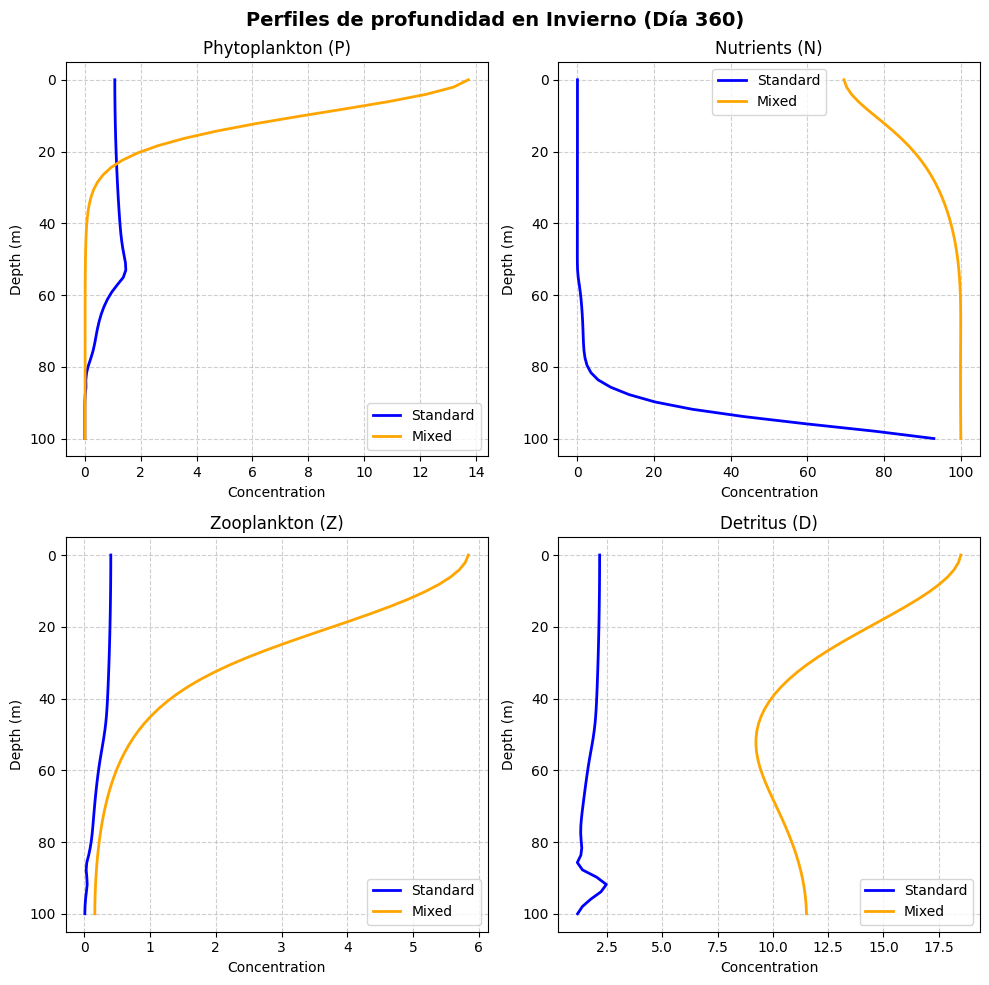

In [38]:
# =========================================================
# GRÁFICA 2: Perfiles de profundidad en INVIERNO
# =========================================================
# Cambiamos el día 180 por el 360 (pleno invierno)
dia_invierno = 360

fig2, axs2 = plt.subplots(2, 2, figsize=(10, 10))
fig2.suptitle(f'Perfiles de profundidad en Invierno (Día {dia_invierno})', fontsize=14, fontweight='bold')

# Y actualizamos las variables de los plots
axs2[0, 0].plot(P_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[0, 0].plot(P_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 0].set_title('Phytoplankton (P)')

axs2[0, 1].plot(N_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[0, 1].plot(N_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 1].set_title('Nutrients (N)')

axs2[1, 0].plot(Z_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[1, 0].plot(Z_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 0].set_title('Zooplankton (Z)')

axs2[1, 1].plot(D_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[1, 1].plot(D_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 1].set_title('Detritus (D)')

for ax in axs2.flat:
    ax.invert_yaxis() 
    ax.set_xlabel('Concentration')
    ax.set_ylabel('Depth (m)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

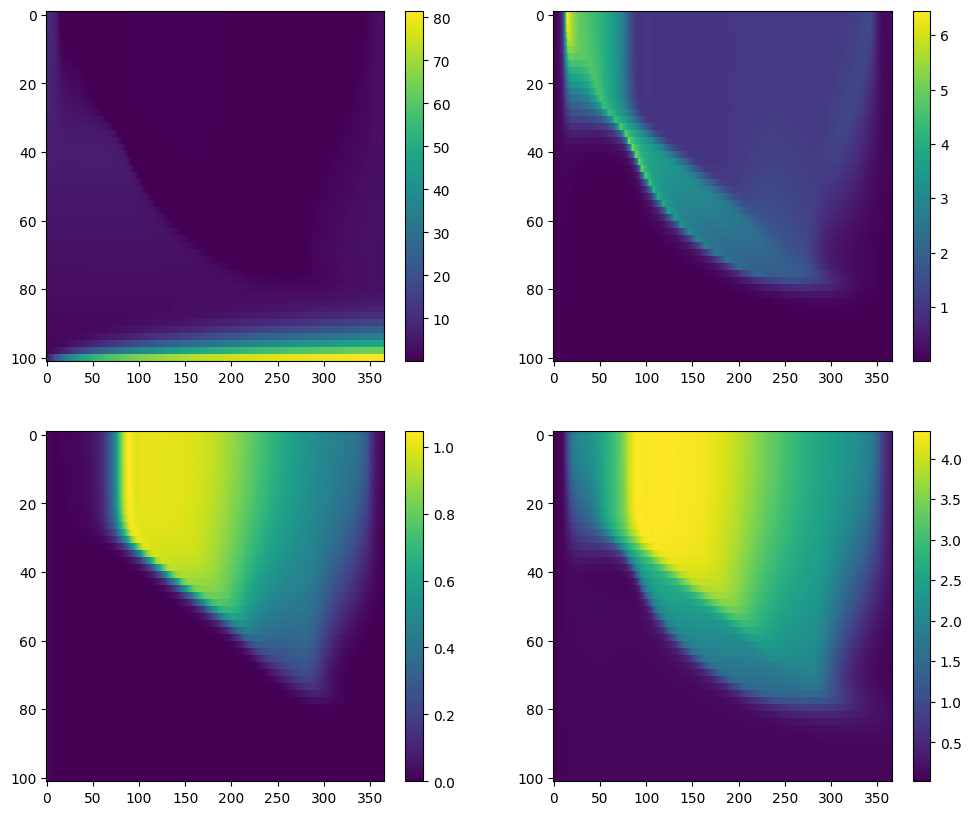

In [39]:
N_std = sol_seasonal.y[0:Nz,:]
P_std = sol_seasonal.y[Nz:2*Nz,:]
Z_std = sol_seasonal.y[2*Nz:3*Nz,:]
D_std = sol_seasonal.y[3*Nz:4*Nz,:]

dias = sol_seasonal.t

fig, axs = plt.subplots(2,2, figsize=(12,10))

c1 = axs[0,0].pcolormesh(dias,z,N_std,shading='auto',cmap='viridis')
axs[0,0].invert_yaxis()
fig.colorbar(c1,ax=axs[0,0])

c2 = axs[0,1].pcolormesh(dias,z,P_std,shading='auto',cmap='viridis')
axs[0,1].invert_yaxis()
fig.colorbar(c2,ax=axs[0,1])

c3 = axs[1,0].pcolormesh(dias,z,Z_std,shading='auto',cmap='viridis')
axs[1,0].invert_yaxis()
fig.colorbar(c3,ax=axs[1,0])

c4 = axs[1,1].pcolormesh(dias,z,D_std,shading='auto',cmap='viridis')
axs[1,1].invert_yaxis()
fig.colorbar(c4,ax=axs[1,1])

plt.show()

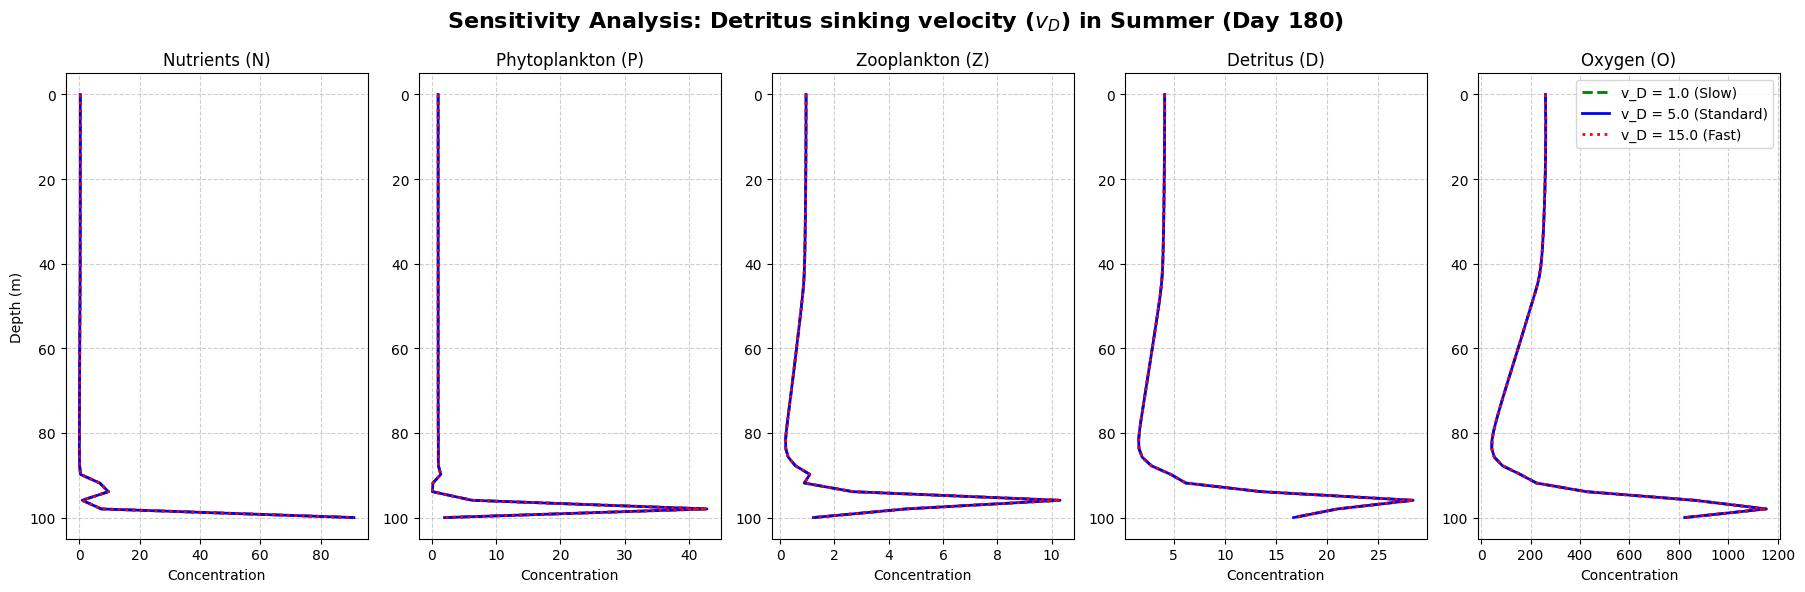

In [40]:
# =========================================================
# APARTADO 3: ANÁLISIS DE SENSIBILIDAD (Parámetro: v_D)
# =========================================================

# 1. Funciones "Envoltorio" para cambiar el parámetro sin romper nada
def modelo_vd_lento(t, y):
    global v_D, high_mixing
    v_D = 1.0           # Detrito cae muy lento
    high_mixing = False # Obligamos a que sea condición Standard
    return npzd_water_column(t, y)

def modelo_vd_normal(t, y):
    global v_D, high_mixing
    v_D = 5.0           # Valor estándar de la tabla
    high_mixing = False 
    return npzd_water_column(t, y)

def modelo_vd_rapido(t, y):
    global v_D, high_mixing
    v_D = 15.0          # Detrito cae muy rápido
    high_mixing = False 
    return npzd_water_column(t, y)

# 2. Simular los tres escenarios (usamos Radau por si las moscas al cambiar parámetros)
sol_lento = solve_ivp(modelo_vd_lento, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_normal = solve_ivp(modelo_vd_normal, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_rapido = solve_ivp(modelo_vd_rapido, [0, 365], y0, t_eval=np.linspace(0, 365, 365))

# 3. Extraer el día 180 (Verano)
dia_verano = 180

def extraer_variables(sol):
    N = sol.y[0:Nz, dia_verano]
    P = sol.y[Nz:2*Nz, dia_verano]
    Z = sol.y[2*Nz:3*Nz, dia_verano]
    D = sol.y[3*Nz:4*Nz, dia_verano]
    O = sol.y[4*Nz:5*Nz, dia_verano]
    return N, P, Z, D, O

N_lento, P_lento, Z_lento, D_lento, O_lento = extraer_variables(sol_lento)
N_normal, P_normal, Z_normal, D_normal, O_normal = extraer_variables(sol_normal)
N_rapido, P_rapido, Z_rapido, D_rapido, O_rapido = extraer_variables(sol_rapido)

# 4. Graficar los 5 perfiles juntos
fig, axs = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('Sensitivity Analysis: Detritus sinking velocity ($v_D$) in Summer (Day 180)', fontsize=16, fontweight='bold')

# Lista de variables y sus títulos para automatizar el gráfico
variables = [
    (N_lento, N_normal, N_rapido, 'Nutrients (N)'),
    (P_lento, P_normal, P_rapido, 'Phytoplankton (P)'),
    (Z_lento, Z_normal, Z_rapido, 'Zooplankton (Z)'),
    (D_lento, D_normal, D_rapido, 'Detritus (D)'),
    (O_lento, O_normal, O_rapido, 'Oxygen (O)')
]

for i, (var_lento, var_normal, var_rapido, title) in enumerate(variables):
    axs[i].plot(var_lento, z, label='v_D = 1.0 (Slow)', color='green', linewidth=2, linestyle='--')
    axs[i].plot(var_normal, z, label='v_D = 5.0 (Standard)', color='blue', linewidth=2)
    axs[i].plot(var_rapido, z, label='v_D = 15.0 (Fast)', color='red', linewidth=2, linestyle=':')
    
    axs[i].invert_yaxis()
    axs[i].set_title(title)
    axs[i].set_ylabel('Depth (m)' if i == 0 else '')
    axs[i].set_xlabel('Concentration')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    if i == 4: # Solo ponemos leyenda en el último para no saturar
        axs[i].legend()

plt.tight_layout()
plt.show()

# IMPORTANTE: Restauramos el valor normal para no afectar simulaciones futuras
v_D = 5.0

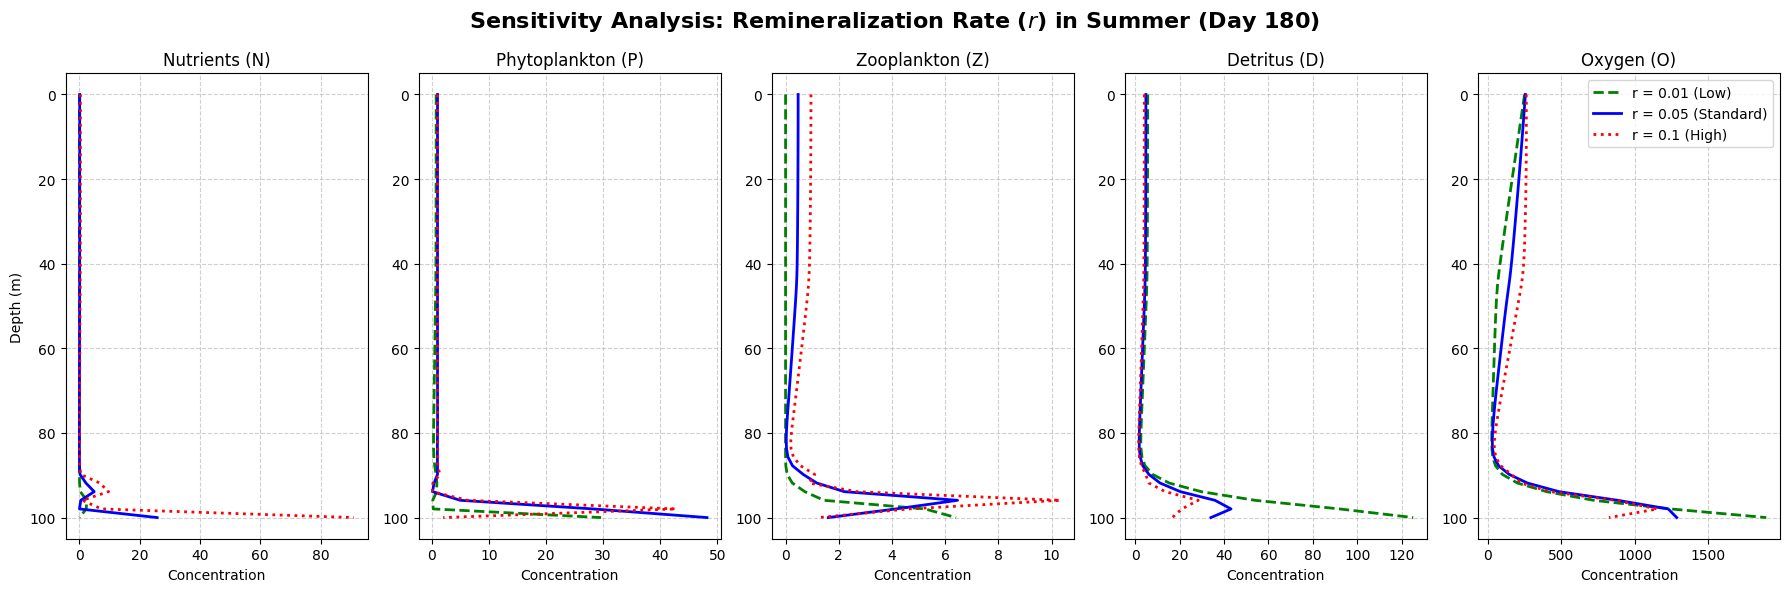

In [41]:
# =========================================================
# APARTADO 3: ANÁLISIS DE SENSIBILIDAD (Parámetro: r)
# =========================================================

# 1. Funciones "Envoltorio" para cambiar el parámetro sin romper nada
def modelo_r_bajo(t, y):
    global r, high_mixing
    r = 0.01          # remineralización muy lenta
    high_mixing = False
    return npzd_water_column(t, y)

def modelo_r_normal(t, y):
    global r, high_mixing
    r = 0.05          # valor estándar de la tabla
    high_mixing = False
    return npzd_water_column(t, y)

def modelo_r_alto(t, y):
    global r, high_mixing
    r = 0.1           # remineralización muy rápida
    high_mixing = False
    return npzd_water_column(t, y)


# 2. Simular los tres escenarios
sol_r_bajo = solve_ivp(modelo_r_bajo, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_r_normal = solve_ivp(modelo_r_normal, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_r_alto = solve_ivp(modelo_r_alto, [0, 365], y0, t_eval=np.linspace(0, 365, 365))


# 3. Extraer el día 180 (Verano)
dia_verano = 180

def extraer_variables(sol):
    N = sol.y[0:Nz, dia_verano]
    P = sol.y[Nz:2*Nz, dia_verano]
    Z = sol.y[2*Nz:3*Nz, dia_verano]
    D = sol.y[3*Nz:4*Nz, dia_verano]
    O = sol.y[4*Nz:5*Nz, dia_verano]
    return N, P, Z, D, O


N_bajo, P_bajo, Z_bajo, D_bajo, O_bajo = extraer_variables(sol_r_bajo)
N_normal, P_normal, Z_normal, D_normal, O_normal = extraer_variables(sol_r_normal)
N_alto, P_alto, Z_alto, D_alto, O_alto = extraer_variables(sol_r_alto)


# 4. Graficar los 5 perfiles juntos
fig, axs = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('Sensitivity Analysis: Remineralization Rate ($r$) in Summer (Day 180)', fontsize=16, fontweight='bold')


variables = [
    (N_bajo, N_normal, N_alto, 'Nutrients (N)'),
    (P_bajo, P_normal, P_alto, 'Phytoplankton (P)'),
    (Z_bajo, Z_normal, Z_alto, 'Zooplankton (Z)'),
    (D_bajo, D_normal, D_alto, 'Detritus (D)'),
    (O_bajo, O_normal, O_alto, 'Oxygen (O)')
]


for i, (var_bajo, var_normal, var_alto, title) in enumerate(variables):

    axs[i].plot(var_bajo, z, label='r = 0.01 (Low)', color='green', linewidth=2, linestyle='--')
    axs[i].plot(var_normal, z, label='r = 0.05 (Standard)', color='blue', linewidth=2)
    axs[i].plot(var_alto, z, label='r = 0.1 (High)', color='red', linewidth=2, linestyle=':')

    axs[i].invert_yaxis()
    axs[i].set_title(title)
    axs[i].set_ylabel('Depth (m)' if i == 0 else '')
    axs[i].set_xlabel('Concentration')
    axs[i].grid(True, linestyle='--', alpha=0.6)

    if i == 4:
        axs[i].legend()

plt.tight_layout()
plt.show()


# IMPORTANTE: restaurar valor estándar
r = 0.05

In [42]:
axs[i].plot(var_lento, z, label='r = 0.01 (Low)', color='green', linestyle='--')
axs[i].plot(var_normal, z, label='r = 0.05 (Standard)', color='blue')
axs[i].plot(var_rapido, z, label='r = 0.1 (High)', color='red', linestyle=':')

C:\Users\mmarc\AppData\Local\Temp\ipykernel_7652\1170939090.py:5: RuntimeWarning: overflow encountered in exp
  light = L0 * np.exp(-(kw*z + kp*cumulative_P))
C:\Users\mmarc\AppData\Local\Temp\ipykernel_7652\1400605967.py:32: RuntimeWarning: invalid value encountered in scalar divide
  g_p = g_p_max * min(light[i]/(light[i]+k_L), N[i]/(N[i]+k_N))
C:\Users\mmarc\AppData\Local\Temp\ipykernel_7652\1170939090.py:5: RuntimeWarning: overflow encountered in multiply
  light = L0 * np.exp(-(kw*z + kp*cumulative_P))


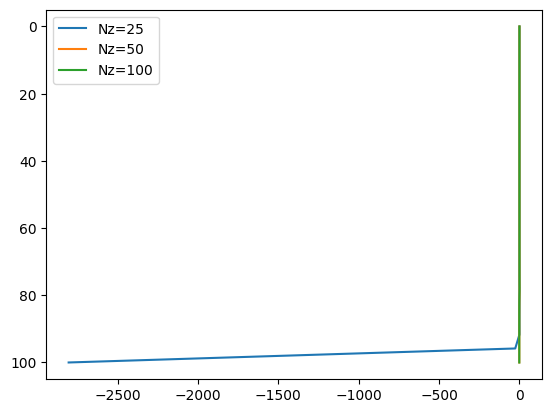

In [43]:
# ================================
# Grid independence test
# ================================

for Nz in [25,50,100]:

    z = np.linspace(0,depth,Nz)
    dz = z[1]-z[0]

    N = np.linspace(10,1,Nz)
    P = np.ones(Nz)*0.05
    Z = np.ones(Nz)*0.02
    D = np.ones(Nz)*0.02
    O = np.zeros(Nz)

    y0 = np.concatenate([N,P,Z,D,O])

    sol = solve_ivp(npzd_water_column, t_span, y0, t_eval=np.linspace(0,365,365))

    P_final = sol.y[Nz:2*Nz,-1]

    plt.plot(P_final,z,label=f"Nz={Nz}")

plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [44]:
!pip install networkx


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


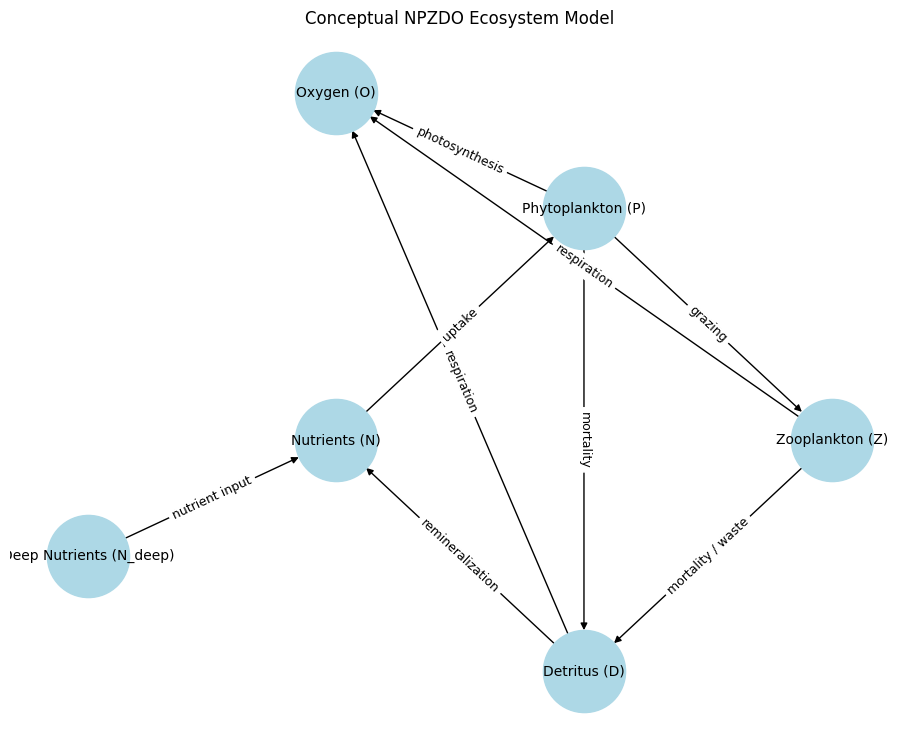

In [45]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Nodos del sistema
nodes = [
    "Nutrients (N)",
    "Phytoplankton (P)",
    "Zooplankton (Z)",
    "Detritus (D)",
    "Oxygen (O)",
    "Deep Nutrients (N_deep)"
]

G.add_nodes_from(nodes)

# Procesos ecológicos
edges = [
    ("Deep Nutrients (N_deep)", "Nutrients (N)", "nutrient input"),
    ("Nutrients (N)", "Phytoplankton (P)", "uptake"),
    ("Phytoplankton (P)", "Zooplankton (Z)", "grazing"),
    ("Phytoplankton (P)", "Detritus (D)", "mortality"),
    ("Zooplankton (Z)", "Detritus (D)", "mortality / waste"),
    ("Detritus (D)", "Nutrients (N)", "remineralization"),
    ("Phytoplankton (P)", "Oxygen (O)", "photosynthesis"),
    ("Detritus (D)", "Oxygen (O)", "respiration"),
    ("Zooplankton (Z)", "Oxygen (O)", "respiration")
]

for u, v, label in edges:
    G.add_edge(u, v, label=label)

# Posiciones manuales para que el diagrama quede claro
pos = {
    "Deep Nutrients (N_deep)": (-2, -0.5),
    "Nutrients (N)": (-1, 0),
    "Phytoplankton (P)": (0, 1),
    "Zooplankton (Z)": (1, 0),
    "Detritus (D)": (0, -1),
    "Oxygen (O)": (-1, 1.5)
}

plt.figure(figsize=(9,7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    font_size=10,
    arrows=True
)

edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Conceptual NPZDO Ecosystem Model")
plt.show()